# LIBRARY IMPORTS

In [ ]:
import pandas as pd
import numpy as np
import string
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#LOAD DATASETS

In [ ]:



df1 = pd.read_excel('/content/AG_NEWS.xlsx')
df2 = pd.read_excel('/content/MSME_DATASET.xlsx')

df1.dropna(how='any', inplace=True)
df2.dropna(how='any', inplace=True)
text_col = 'text'
label_col = 'label'

X1 = df1[text_col].astype(str)
y1 = df1[label_col]

X2 = df2[text_col].astype(str)
y2 = df2[label_col]

display(df1.head(10))
display(df2.head(10))

,text,label
0,Wall St. Bears Claw Back Into the Black (Reute...,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,Business
3,Iraq Halts Oil Exports from Main Southern Pipe...,Business
4,"Oil prices soar to all-time record, posing new...",Business
5,"Stocks End Up, But Near Year Lows (Reuters) Re...",Business
6,Money Funds Fell in Latest Week (AP) AP - Asse...,Business
7,Fed minutes show dissent over inflation (USATO...,Business
8,Safety Net (Forbes.com) Forbes.com - After ear...,Business
9,Wall St. Bears Claw Back Into the Black NEW Y...,Business


,text,label
0,"ASSISTANT DIRECTOR, ENFORCEMENT DIRECTORATE .....",02_quality_dispute
1,"State of Maharashtra) Office Notes, Office Mem...",03_no_contract
2,Bangalore District Court M/S Cauvery Distribut...,02_quality_dispute
3,M/s Suri Electricals and Ceramics .....Respond...,01_delayed_payment
4,"Delhi High Court Metal Forgings Pvt. Ltd., New...",03_no_contract
5,M/s Cosmas Research Lab Ltd. ... Respondent(s)...,04_partial_payment
6,West Bengal State Micro Small Enterprises Faci...,01_delayed_payment
7,Lok Sabha Debates Regarding Swavalamban Scheme...,04_partial_payment
8,"1.The Chief Engineer (A/C), TWAD Board, No.30,...",04_partial_payment
9,Piyush Periwal & Ors. ...Respondents Present: ...,04_partial_payment


#TOKENIZATION

In [ ]:
def apply_tokenization(text):
    return word_tokenize(text)

tokens_1 = X1.apply(apply_tokenization)
tokens_2 = X2.apply(apply_tokenization)
print("Word found:Dataset 1 ", len(tokens_1))
print(tokens_1)
print("Word found:Dataset 2 ", len(tokens_2))
print(tokens_2)

Word found:Dataset 1  2000
0       [Wall, St., Bears, Claw, Back, Into, the, Blac...
1       [Carlyle, Looks, Toward, Commercial, Aerospace...
2       [Oil, and, Economy, Cloud, Stocks, ', Outlook,...
3       [Iraq, Halts, Oil, Exports, from, Main, Southe...
4       [Oil, prices, soar, to, all-time, record, ,, p...
                              ...                        
1995    [Google, Interview, Is, Draw, for, Latest, Pla...
1996    [Williamson, Gets, Third, Opinion, on, Elbow, ...
1997    [Iran, Threatens, Israel, on, Nuclear, Reactor...
1998    [Grim, funeral, service, held, for, Burundi, m...
1999    [Borders, Profits, Rise, ,, Raises, Outlook, N...
Name: text, Length: 2000, dtype: object
Word found:Dataset 2  2000
0       [ASSISTANT, DIRECTOR, ,, ENFORCEMENT, DIRECTOR...
1       [State, of, Maharashtra, ), Office, Notes, ,, ...
2       [Bangalore, District, Court, M/S, Cauvery, Dis...
3       [M/s, Suri, Electricals, and, Ceramics, .....,...
4       [Delhi, High, Court, Metal, 

#CASE FOLDING

In [ ]:
def apply_case_folding(tokens):
    return [x.lower() for x in tokens]

tokens_1 = tokens_1.apply(apply_case_folding)
tokens_2 = tokens_2.apply(apply_case_folding)
print("Lower case:Dataset 1 ", len(tokens_1))
print(tokens_1)
print("Lower case:Dataset 2 ", len(tokens_2))
print(tokens_2)

Lower case:Dataset 1  2000
0       [wall, st., bears, claw, back, into, the, blac...
1       [carlyle, looks, toward, commercial, aerospace...
2       [oil, and, economy, cloud, stocks, ', outlook,...
3       [iraq, halts, oil, exports, from, main, southe...
4       [oil, prices, soar, to, all-time, record, ,, p...
                              ...                        
1995    [google, interview, is, draw, for, latest, pla...
1996    [williamson, gets, third, opinion, on, elbow, ...
1997    [iran, threatens, israel, on, nuclear, reactor...
1998    [grim, funeral, service, held, for, burundi, m...
1999    [borders, profits, rise, ,, raises, outlook, n...
Name: text, Length: 2000, dtype: object
Lower case:Dataset 2  2000
0       [assistant, director, ,, enforcement, director...
1       [state, of, maharashtra, ), office, notes, ,, ...
2       [bangalore, district, court, m/s, cauvery, dis...
3       [m/s, suri, electricals, and, ceramics, .....,...
4       [delhi, high, court, metal, 

#SYNONYM SUBSTITUTION

In [ ]:
synonyms = {
    "won't": "will not",
    "can't": "cannot",
    "n't": "not",
    "good": "nice",
    "bad": "poor",
    "big": "large",
    "small": "little",
    "happy": "glad",
    "quick": "fast",
    "begin": "start",
    "prices" : "price"
}

def apply_synonym_substitution(tokens):
    replaced_tokens = []

    for t in tokens:
        if t in synonyms:
            t = synonyms[t]

        replaced_tokens.append(t)

    return replaced_tokens

tokens_1 = tokens_1.apply(apply_synonym_substitution)
tokens_2 = tokens_2.apply(apply_synonym_substitution)
print("Substitute Synonyms: Dataset 1 ", len(tokens_1))
print(tokens_1)
print("Substitute Synonyms: Dataset 2 ", len(tokens_2))
print(tokens_2)

Substitute Synonyms: Dataset 1  2000
0       [wall, st., bears, claw, back, into, the, blac...
1       [carlyle, looks, toward, commercial, aerospace...
2       [oil, and, economy, cloud, stocks, ', outlook,...
3       [iraq, halts, oil, exports, from, main, southe...
4       [oil, price, soar, to, all-time, record, ,, po...
                              ...                        
1995    [google, interview, is, draw, for, latest, pla...
1996    [williamson, gets, third, opinion, on, elbow, ...
1997    [iran, threatens, israel, on, nuclear, reactor...
1998    [grim, funeral, service, held, for, burundi, m...
1999    [borders, profits, rise, ,, raises, outlook, n...
Name: text, Length: 2000, dtype: object
Substitute Synonyms: Dataset 2  2000
0       [assistant, director, ,, enforcement, director...
1       [state, of, maharashtra, ), office, notes, ,, ...
2       [bangalore, district, court, m/s, cauvery, dis...
3       [m/s, suri, electricals, and, ceramics, .....,...
4       [delhi, 

#STEMMING

In [ ]:
stemmer = PorterStemmer()

def apply_stemming_and_join(tokens):
    stemmed_words = [stemmer.stem(word) for word in tokens]
    return " ".join(stemmed_words)

X1_clean = tokens_1.apply(apply_stemming_and_join)
X2_clean = tokens_2.apply(apply_stemming_and_join)
print("Stems: Dataset 1 ", len(tokens_1))
print(tokens_1)
print("Stems: Dataset 2 ", len(tokens_2))
print(tokens_2)

Stems: Dataset 1  2000
0       [wall, st., bears, claw, back, into, the, blac...
1       [carlyle, looks, toward, commercial, aerospace...
2       [oil, and, economy, cloud, stocks, ', outlook,...
3       [iraq, halts, oil, exports, from, main, southe...
4       [oil, price, soar, to, all-time, record, ,, po...
                              ...                        
1995    [google, interview, is, draw, for, latest, pla...
1996    [williamson, gets, third, opinion, on, elbow, ...
1997    [iran, threatens, israel, on, nuclear, reactor...
1998    [grim, funeral, service, held, for, burundi, m...
1999    [borders, profits, rise, ,, raises, outlook, n...
Name: text, Length: 2000, dtype: object
Stems: Dataset 2  2000
0       [assistant, director, ,, enforcement, director...
1       [state, of, maharashtra, ), office, notes, ,, ...
2       [bangalore, district, court, m/s, cauvery, dis...
3       [m/s, suri, electricals, and, ceramics, .....,...
4       [delhi, high, court, metal, forgings

#PUNCATION REMOVAL

In [ ]:
def apply_punctuation_removal(tokens):
    text_remove_mapping = str.maketrans("", "", string.punctuation)
    clean_tokens = [t.translate(text_remove_mapping) for t in tokens]
    return [t for t in clean_tokens if t.strip() != ""]

tokens_1 = tokens_1.apply(apply_punctuation_removal)
tokens_2 = tokens_2.apply(apply_punctuation_removal)
print("Puncuation Remove : Dataset 1 ", len(tokens_1))
print(tokens_1)
print("Puncuation Remove : Dataset 2 ", len(tokens_2))
print(tokens_2)


Puncuation Remove : Dataset 1  2000
0       [wall, st, bears, claw, back, into, the, black...
1       [carlyle, looks, toward, commercial, aerospace...
2       [oil, and, economy, cloud, stocks, outlook, re...
3       [iraq, halts, oil, exports, from, main, southe...
4       [oil, price, soar, to, alltime, record, posing...
                              ...                        
1995    [google, interview, is, draw, for, latest, pla...
1996    [williamson, gets, third, opinion, on, elbow, ...
1997    [iran, threatens, israel, on, nuclear, reactor...
1998    [grim, funeral, service, held, for, burundi, m...
1999    [borders, profits, rise, raises, outlook, new,...
Name: text, Length: 2000, dtype: object
Puncuation Remove : Dataset 2  2000
0       [assistant, director, enforcement, directorate...
1       [state, of, maharashtra, office, notes, office...
2       [bangalore, district, court, ms, cauvery, dist...
3       [ms, suri, electricals, and, ceramics, respond...
4       [delhi, hi

#STOP WORDS REMOVAL

In [ ]:
stop_words = set(stopwords.words("english"))

def apply_stopwords_removal(tokens):
    return [word for word in tokens if word not in stop_words]

X1_clean = tokens_1.apply(apply_stopwords_removal)
X2_clean = tokens_2.apply(apply_stopwords_removal)
print("Stop words remove: Dataset 1 ", len(X1_clean))
print(tokens_1)
print("Stop words remove: Dataset 2 ", len(X2_clean))
print(tokens_2)

Stop words remove: Dataset 1  2000
0       [wall, st, bears, claw, back, into, the, black...
1       [carlyle, looks, toward, commercial, aerospace...
2       [oil, and, economy, cloud, stocks, outlook, re...
3       [iraq, halts, oil, exports, from, main, southe...
4       [oil, price, soar, to, alltime, record, posing...
                              ...                        
1995    [google, interview, is, draw, for, latest, pla...
1996    [williamson, gets, third, opinion, on, elbow, ...
1997    [iran, threatens, israel, on, nuclear, reactor...
1998    [grim, funeral, service, held, for, burundi, m...
1999    [borders, profits, rise, raises, outlook, new,...
Name: text, Length: 2000, dtype: object
Stop words remove: Dataset 2  2000
0       [assistant, director, enforcement, directorate...
1       [state, of, maharashtra, office, notes, office...
2       [bangalore, district, court, ms, cauvery, dist...
3       [ms, suri, electricals, and, ceramics, respond...
4       [delhi, high

# TRAIN AND TEST DATA

In [ ]:
from sklearn.model_selection import train_test_split

X1_train, X1_test, y1_train, y1_test = train_test_split(X1_clean, y1, test_size=0.2, random_state=42)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2_clean, y2, test_size=0.2, random_state=42)


#CONVERT LIST AS STRING

In [ ]:
X1_train = X1_train.apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
X1_test = X1_test.apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
X2_train = X2_train.apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))
X2_test = X2_test.apply(lambda x: " ".join(x) if isinstance(x, list) else str(x))

#BoW

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
count_vector = CountVectorizer()
X1_train_bow = count_vector.fit_transform(X1_train)
X1_test_bow = count_vector.transform(X1_test)

count_vector_2 = CountVectorizer()
X2_train_bow = count_vector_2.fit_transform(X2_train)
X2_test_bow = count_vector_2.transform(X2_test)



#TF_IDF

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
X1_train_tfidf = tfidf_vectorizer.fit_transform(X1_train)
X1_test_tfidf = tfidf_vectorizer.transform(X1_test)

tfidf_vectorizer_2 = TfidfVectorizer()
X2_train_tfidf = tfidf_vectorizer_2.fit_transform(X2_train)
X2_test_tfidf = tfidf_vectorizer_2.transform(X2_test)

#EVALUATION & ALGORITHM APPLICATION

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

def evaluate_and_print(model, X_train, y_train, X_test, y_test, model_name, rep, dataset):
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    acc = accuracy_score(y_test, predictions)
    prec = precision_score(y_test, predictions, average='weighted', zero_division=0)
    rec = recall_score(y_test, predictions, average='weighted', zero_division=0)
    f1 = f1_score(y_test, predictions, average='weighted', zero_division=0)
    cm = confusion_matrix(y_test, predictions)

    print(model_name, "|", rep, "|", dataset)
    print("Accuracy: ", acc)
    print("Precision:", prec)
    print("Recall:   ", rec)
    print("F1 Score: ", f1)
    print("-" * 40)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)
    cm_display.plot(cmap=plt.cm.Blues, ax=ax1)
    ax1.set_title(f"Confusion Matrix: {model_name} ({rep})")

    metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    metrics_values = [acc, prec, rec, f1]

    bars = ax2.bar(metrics_names, metrics_values, color=['#4CAF50', '#2196F3', '#FFC107', '#F44336'])
    ax2.set_ylim(0, 1.1)
    ax2.set_title(f"Performance Metrics: {model_name} ({rep})")
    ax2.set_ylabel("Score")

    for bar in bars:
        yval = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, yval + 0.02, round(yval, 3), ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return round(acc, 4)

#NAIVE BIAS

Naive Bayes | BoW | Dataset 1
Accuracy:  0.825
Precision: 0.826734340354767
Recall:    0.825
F1 Score:  0.8225390122200412
----------------------------------------


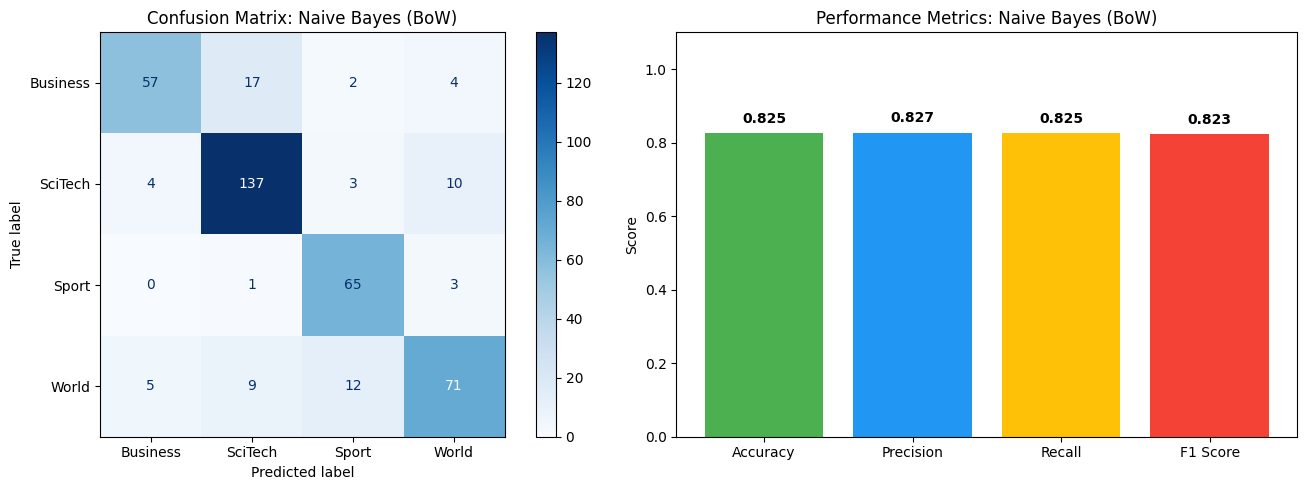

Naive Bayes | TF-IDF | Dataset 1
Accuracy:  0.7625
Precision: 0.8001482424357996
Recall:    0.7625
F1 Score:  0.7543733862376036
----------------------------------------


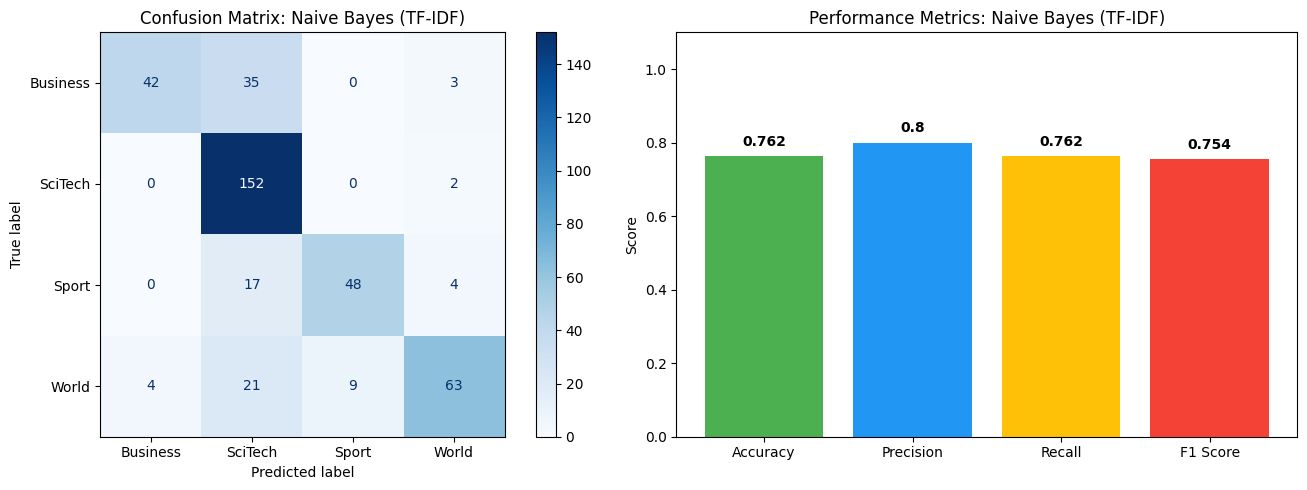

Naive Bayes | BoW | Dataset 2
Accuracy:  0.8325
Precision: 0.8301152400441193
Recall:    0.8325
F1 Score:  0.8280268718749052
----------------------------------------


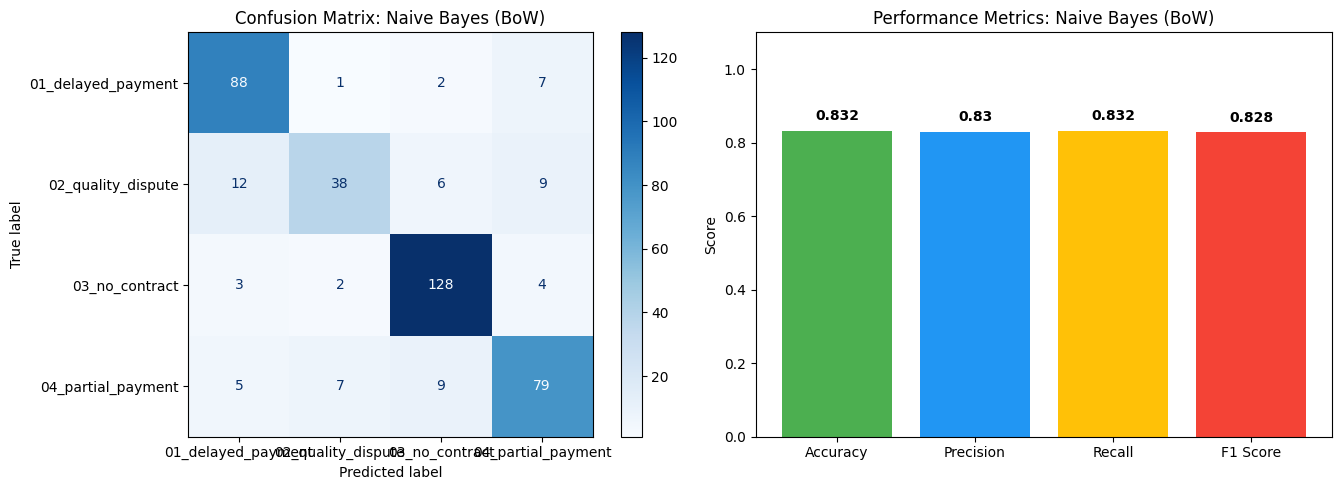

Naive Bayes | TF-IDF | Dataset 2
Accuracy:  0.6775
Precision: 0.7106835534164301
Recall:    0.6775
F1 Score:  0.624805293469317
----------------------------------------


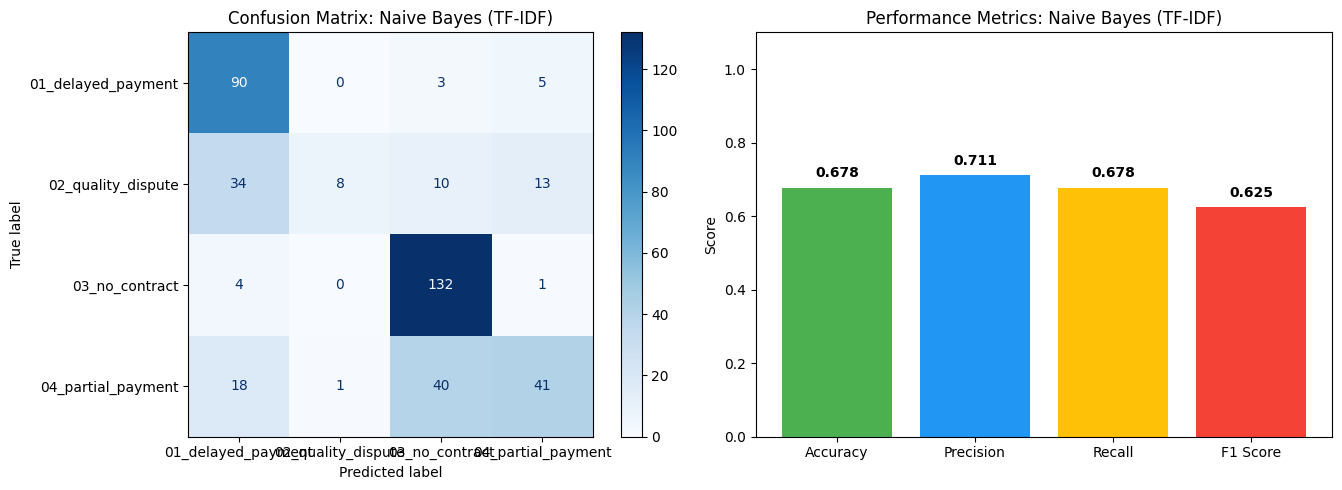

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

nb_d1_bow = evaluate_and_print(nb_model, X1_train_bow, y1_train, X1_test_bow, y1_test, "Naive Bayes", "BoW", "Dataset 1")
nb_d1_tfidf = evaluate_and_print(nb_model, X1_train_tfidf, y1_train, X1_test_tfidf, y1_test, "Naive Bayes", "TF-IDF", "Dataset 1")
nb_d2_bow = evaluate_and_print(nb_model, X2_train_bow, y2_train, X2_test_bow, y2_test, "Naive Bayes", "BoW", "Dataset 2")
nb_d2_tfidf = evaluate_and_print(nb_model, X2_train_tfidf, y2_train, X2_test_tfidf, y2_test, "Naive Bayes", "TF-IDF", "Dataset 2")

#LOGESTIC REGRESSION

Logistic Regression | BoW | Dataset 1
Accuracy:  0.79
Precision: 0.7924187806873977
Recall:    0.79
F1 Score:  0.7879634127610728
----------------------------------------


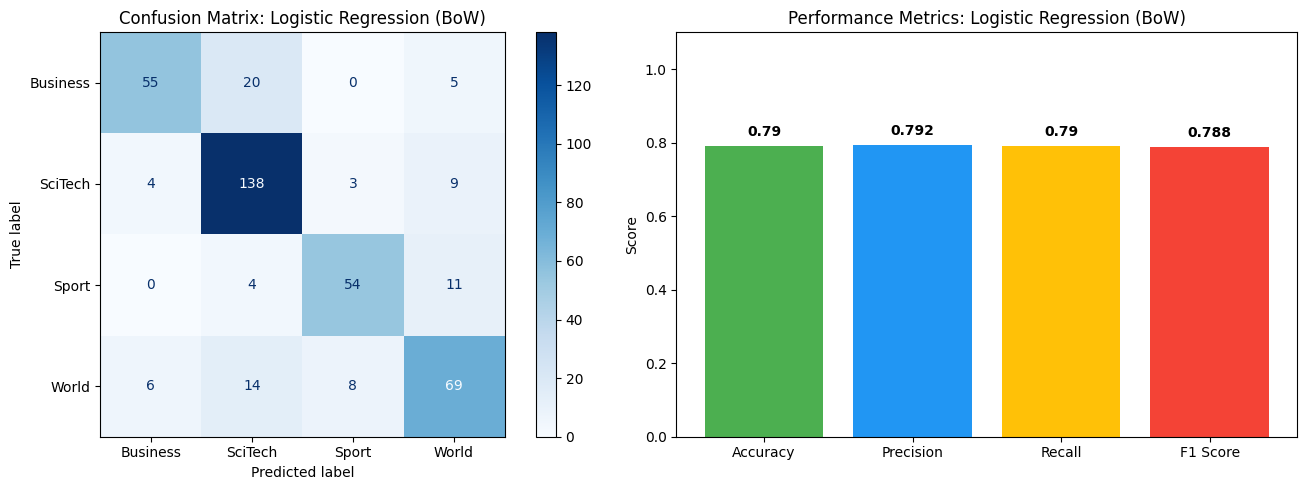

Logistic Regression | TF-IDF | Dataset 1
Accuracy:  0.775
Precision: 0.8015227091005983
Recall:    0.775
F1 Score:  0.7696321834361833
----------------------------------------


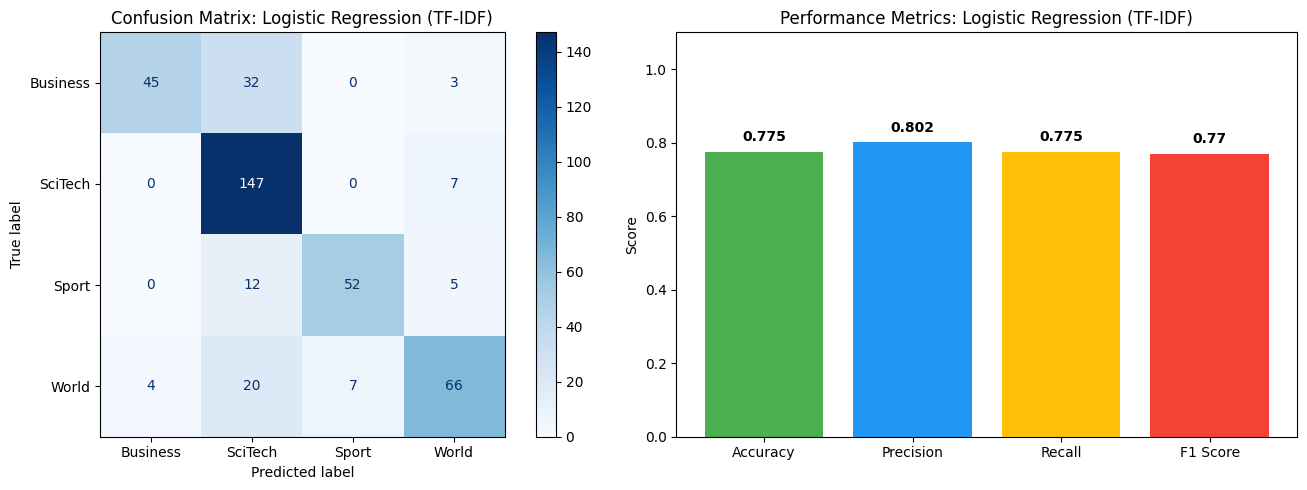

Logistic Regression | BoW | Dataset 2
Accuracy:  0.8525
Precision: 0.8511350692064523
Recall:    0.8525
F1 Score:  0.8505991055592506
----------------------------------------


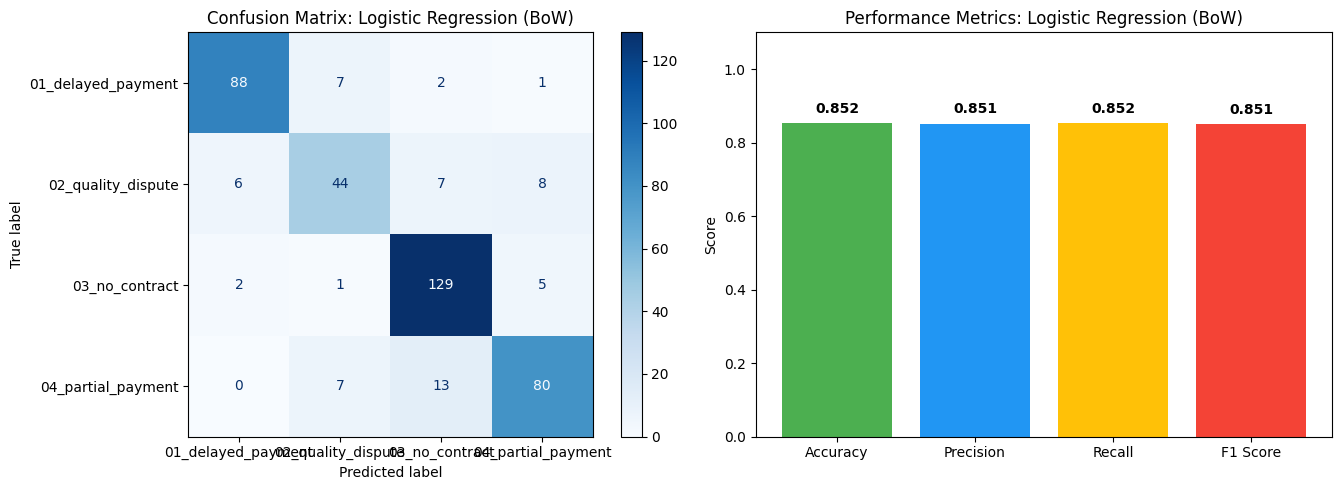

Logistic Regression | TF-IDF | Dataset 2
Accuracy:  0.815
Precision: 0.8128036987522281
Recall:    0.815
F1 Score:  0.8075511976285022
----------------------------------------


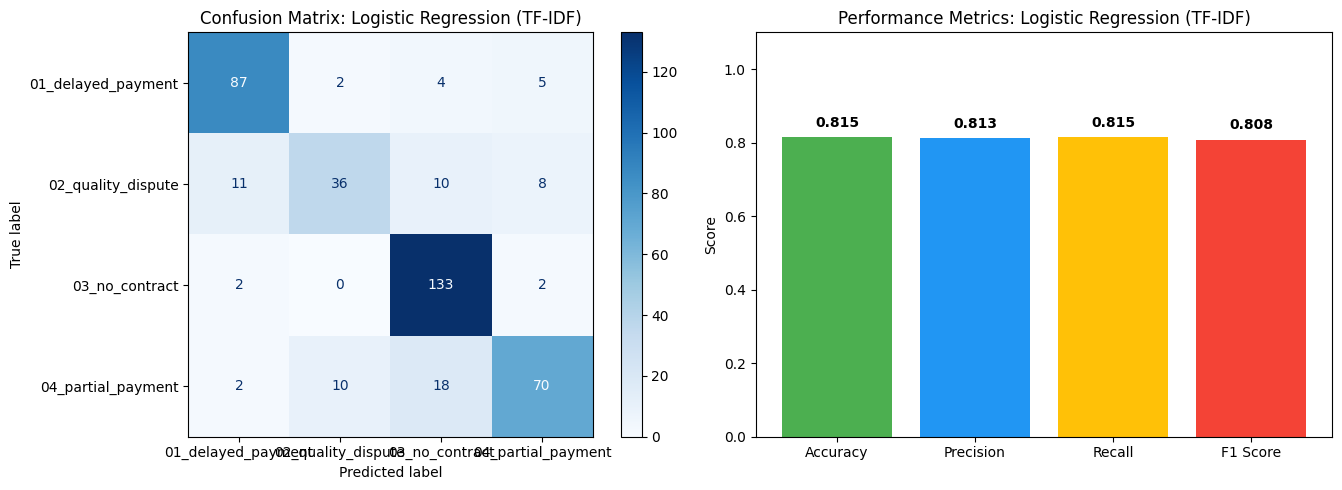

In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_d1_bow = evaluate_and_print(lr_model, X1_train_bow, y1_train, X1_test_bow, y1_test, "Logistic Regression", "BoW", "Dataset 1")
lr_d1_tfidf = evaluate_and_print(lr_model, X1_train_tfidf, y1_train, X1_test_tfidf, y1_test, "Logistic Regression", "TF-IDF", "Dataset 1")
lr_d2_bow = evaluate_and_print(lr_model, X2_train_bow, y2_train, X2_test_bow, y2_test, "Logistic Regression", "BoW", "Dataset 2")
lr_d2_tfidf = evaluate_and_print(lr_model, X2_train_tfidf, y2_train, X2_test_tfidf, y2_test, "Logistic Regression", "TF-IDF", "Dataset 2")

#SVM

Linear SVC | BoW | Dataset 1
Accuracy:  0.8025
Precision: 0.8015768539244911
Recall:    0.8025
F1 Score:  0.8010319056585583
----------------------------------------


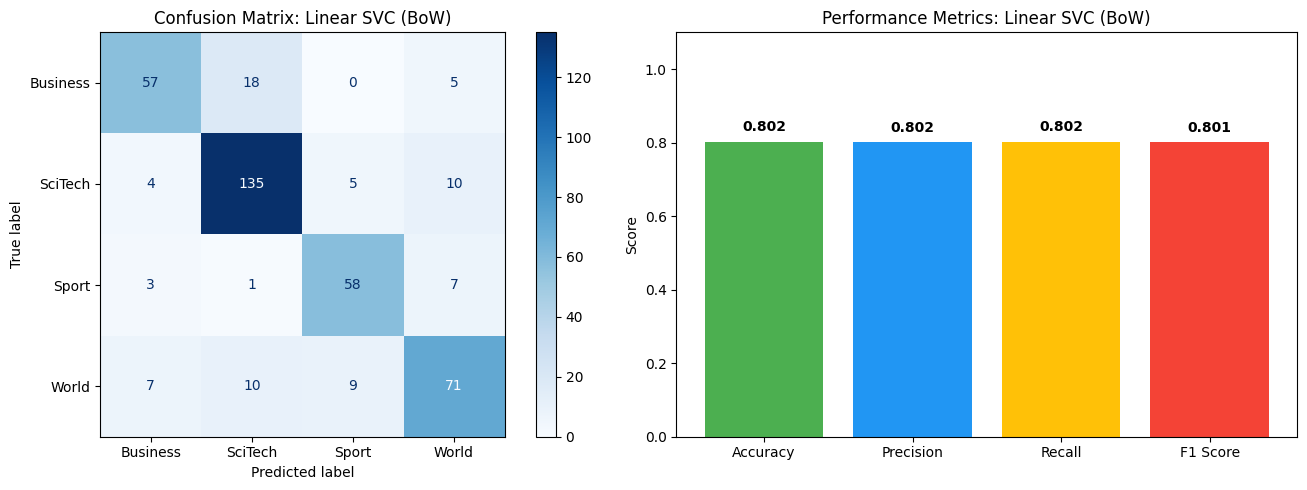

Linear SVC | TF-IDF | Dataset 1
Accuracy:  0.83
Precision: 0.8323442043647927
Recall:    0.83
F1 Score:  0.8273606872579475
----------------------------------------


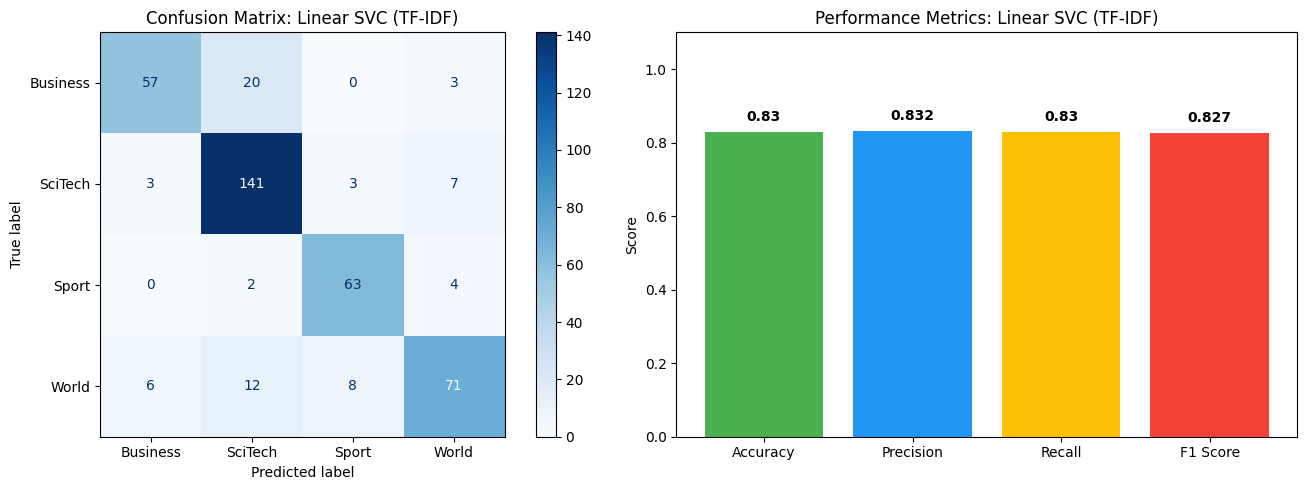

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Linear SVC | BoW | Dataset 2
Accuracy:  0.8475
Precision: 0.8459456874831061
Recall:    0.8475
F1 Score:  0.8453069669051487
----------------------------------------


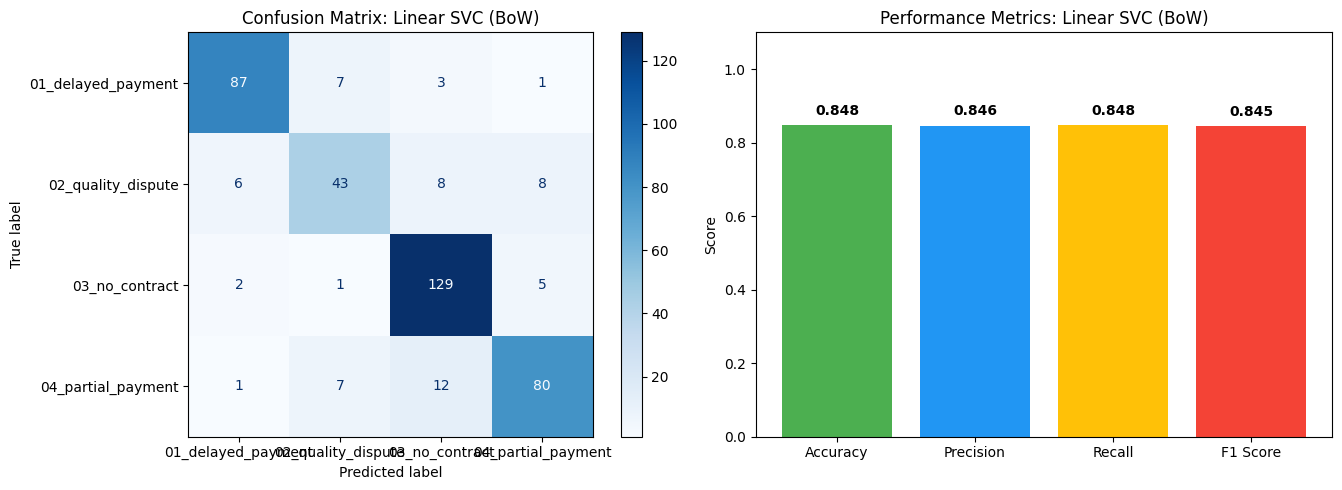

Linear SVC | TF-IDF | Dataset 2
Accuracy:  0.8675
Precision: 0.8669503378809129
Recall:    0.8675
F1 Score:  0.8648159246575342
----------------------------------------


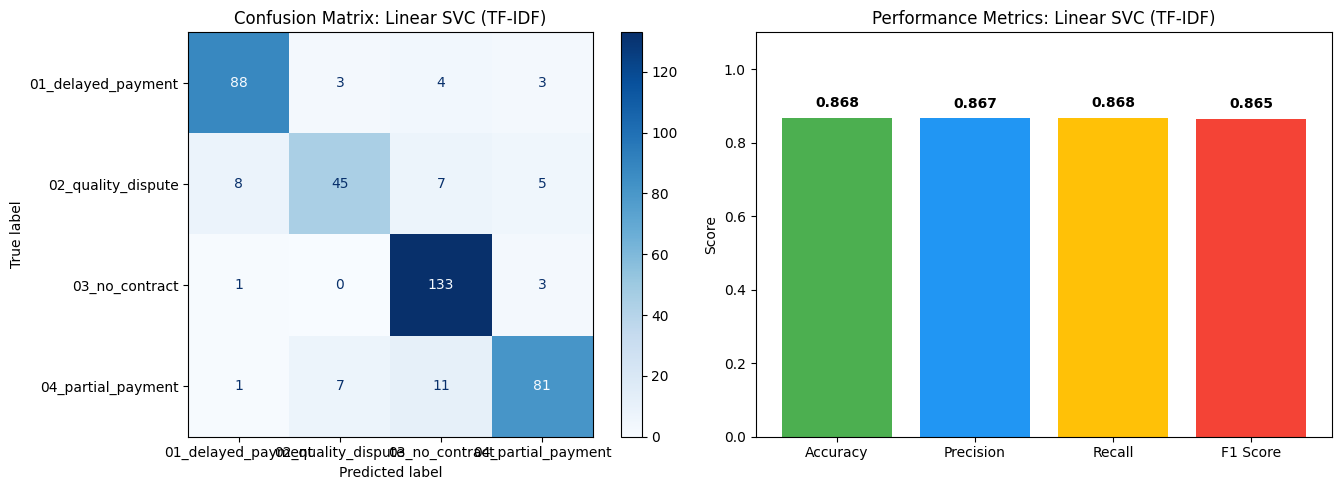

In [ ]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_d1_bow = evaluate_and_print(svm_model, X1_train_bow, y1_train, X1_test_bow, y1_test, "Linear SVC", "BoW", "Dataset 1")
svm_d1_tfidf = evaluate_and_print(svm_model, X1_train_tfidf, y1_train, X1_test_tfidf, y1_test, "Linear SVC", "TF-IDF", "Dataset 1")
svm_d2_bow = evaluate_and_print(svm_model, X2_train_bow, y2_train, X2_test_bow, y2_test, "Linear SVC", "BoW", "Dataset 2")
svm_d2_tfidf = evaluate_and_print(svm_model, X2_train_tfidf, y2_train, X2_test_tfidf, y2_test, "Linear SVC", "TF-IDF", "Dataset 2")